In [1]:
import vald_api_utilities as vau
import vald_nordbord_api as vna

%load_ext autoreload
%autoreload 2

# Initialize organizational parameters
Vald should provide a "Client ID", "Client Secret", and a "Tenant ID". The "Tenant ID" is some what interchangable with the "Team ID" and can be acquired through the External Tenant API call.

In [2]:
# Read credentials using vald_api_utilities function
creds = vau.read_credentials()

client_id = creds['client_id']
client_secret = creds['client_secret']
tenantId = creds['tenant_id']

print(f"Client ID: {client_id}")
print(f"Client Secret: {client_secret}")
print(f"Tenant ID: {tenantId}")

Client ID: 
Client Secret: 
Tenant ID: 


### Initialize Vald API Class Function  
The class functions as a wrapper for the External Tenant and External Profile API calls.

In [3]:
vald = vau.vald_api(client_id,client_secret,tenant_id=tenantId)

### Step 1 - Get Token
"get_token()" should always be your first api call as this gives you a temparoray access key to be used for all future calls

In [4]:
vald.get_token()

#### OPTIONAL - "get_all_tenants()" or "get_tenant_info()"
Use "get_all_tenants()" to return a dictionary with all tenants.
Use "get_tenant_info()" to return a dictionary with additional inforamtion about specific tenant.

In [5]:
vald.get_all_tenants()
# vald.tenants

In [6]:
# If not initializing class function with "tenant ID" then enter 
# tenant_id here, using commented example.
# vald.get_tenant_info(tenant_id=vald.tenants[0]['id'])

# If initialized class function with "Tenant ID" then use the following.
vald.get_tenant_info()
# vald.tenant_info

### Step 2 - Get information on the categories and groups
Using the specified "Tenant ID", get information on the categories and groups for the "Tenant ID".

In [7]:
# Generated dataframe containing ID and name of each category
vald.get_tenant_categories()
vald.categories_df

,id,syncId,name
0,306f33af-2939-480b-bbd7-2ce643c888f0,None,Uncategorised
1,3a32a047-1292-49f1-a8aa-8f830ea58ac8,None,Position
2,1fdaf750-970a-4047-badc-945e6e6994cf,None,Team
3,2828d5d2-ce26-4297-b4c1-a16039889a86,None,Sport


In [8]:
# Generated dataframe of groups ID, name, and category ID. 
vald.get_tenant_groups()
vald.groups_df.head()

,id,name,categoryId,syncId
0,286167da-0a3c-4da9-9b09-316ba9f6e089,Acro and Tumbling,1fdaf750-970a-4047-badc-945e6e6994cf,None
1,61694101-179d-483f-a8c7-8c5632362760,Acro and Tumbling,2828d5d2-ce26-4297-b4c1-a16039889a86,None
2,20588edf-7394-489c-a502-1f0c10c25db8,Baseball,2828d5d2-ce26-4297-b4c1-a16039889a86,None
3,f26a6a9c-7232-4d01-a214-b3f8584ba293,Baseball,1fdaf750-970a-4047-badc-945e6e6994cf,None
4,fa4489a4-4a0e-4003-869d-3a7565e82fe4,Football,2828d5d2-ce26-4297-b4c1-a16039889a86,None


### Step 3 - Get all profiles in a specific group.
Use "get_group_profiles()" to generate dataframe of all athlete profiles in a given group based on the category and group dataframe. It is important to generate both the group and category dateframes as both of these will used to identify the correct IDs.

In [17]:
# categoru_name is used to get the category ID which is used to get the correct group ID.
# This insures that when there are groups' with the same name in different categories, 
# the correct group ID is found.

# Replace 'Staff' (group name) with desired value.
vald.get_group_profiles('Staff',category_name='Team')
#vald.profile_df.head()

# Nordboard API Call
After gathering the tenant ID and profile IDs we can use this information to pull force decks results.

In [18]:
# Initialize Force Decks class function with tenant ID and header from Vald class function.
nordbord = vna.nordbord_api(vald.tenant_id,vald.header,region='USA')

### Step 1 - Get a collection of tests
Using "get_multiple_tests()", you need to include a start and stop date for the period you'd like to pull tests from. You can also provide a modified date and or a profile ID to filter on. If no modified data is given then the start date will be used for the modified date. If no profile ID is given then that will not be included in API call.

Start and stop date should be within 6 months of each other

In [39]:
modified_date = '18/05/2026' # date must be in "dd/mm/yyyy" format
profileID = vald.profile_df.loc[2,'profileId']

nordbord.get_tests(modified_date,profileID=profileID)
nordbord.tests_df.head()

{'/tests/v2': '', '?TenantId=': '61476d2d-917a-4b2e-b2f6-e43346d2cb66', '&ModifiedFromUtc=': '2026-05-18T05%3A00%3A00.000Z', '&ProfileId=': 'b087502b-e06f-46c2-8ce0-11fd2817b416'}
<Response [200]>
{'/tests/v2': '', '?TenantId=': '61476d2d-917a-4b2e-b2f6-e43346d2cb66', '&ModifiedFromUtc=': '2026-05-21T14%3A55%3A25.233Z', '&ProfileId=': 'b087502b-e06f-46c2-8ce0-11fd2817b416'}
<Response [200]>
Duplicate modifiedDateUtc values observed. Dropping duplicate entries and ending loop to prevent infinite loop. Please investigate the modifiedDateUtc values for the returned test entries to ensure they are updating as expected.


,profileId,testId,modifiedDateUtc,testDateUtc,testTypeId,testTypeName,notes,device,leftAvgForce,leftImpulse,leftMaxForce,leftTorque,leftCalibration,leftRepetitions,rightAvgForce,rightImpulse,rightMaxForce,rightTorque,rightCalibration,rightRepetitions
0,b087502b-e06f-46c2-8ce0-11fd2817b416,d9cc6fe8-15cf-410e-9a51-65084fcf6ce3,2026-05-21T14:54:56.951Z,2026-05-21T14:54:56.759Z,596a6004-553f-4afa-aef0-1474903b462e,Nordic,,NordBord-3332,220.25,370.158125,220.25,78.298875,0.0,1,312.0,490.724062,312.0,110.9160,0.0,1
1,b087502b-e06f-46c2-8ce0-11fd2817b416,027902d9-5a14-41c2-81bf-1464bef76d51,2026-05-21T14:55:21.993Z,2026-05-21T14:55:21.853Z,596a6004-553f-4afa-aef0-1474903b462e,Nordic,,NordBord-2548,0.00,0.000000,0.00,0.000000,0.0,0,0.0,0.000000,0.0,0.0000,0.0,0
2,b087502b-e06f-46c2-8ce0-11fd2817b416,29bc6ed4-5e67-46d2-a152-5caf3b4fbf6e,2026-05-21T14:55:25.233Z,2026-05-21T14:55:24.970Z,596a6004-553f-4afa-aef0-1474903b462e,Nordic,,NordBord-2558,195.25,277.765000,195.25,69.411375,0.0,1,181.0,256.230000,181.0,64.3455,0.0,1


In [44]:
start_date = '18/05/2026' # date must be in "dd/mm/yyyy" format
end_date = '23/05/2026' # date must be in "dd/mm/yyyy" format

nordbord.get_multiple_tests(start_date, end_date)
nordbord.tests_df.head()

,athleteId,testId,modifiedUtc,testDateUtc,testTypeId,testTypeName,notes,device,leftAvgForce,leftImpulse,leftMaxForce,leftTorque,leftCalibration,rightAvgForce,rightImpulse,rightMaxForce,rightTorque,rightCalibration,leftRepetitions,rightRepetitions
0,a097e817-6a12-41f1-aca8-97279d89f7a5,d0cb67b5-0c11-4c0a-9b80-24f546dc0943,2026-05-21T18:15:14.610Z,2026-05-21T18:15:14.363Z,596a6004-553f-4afa-aef0-1474903b462e,Nordic,,NordBord-1490,530.083333,6340.028750,554.75,227.170125,0.0,547.666667,7254.360313,551.00,225.634500,0.0,3,3
1,ed456e5b-b81d-49da-81c0-c675375cf88a,ea3e09a9-4f80-4032-86ce-c58f65467b97,2026-05-21T18:09:44.410Z,2026-05-21T18:09:44.152Z,596a6004-553f-4afa-aef0-1474903b462e,Nordic,,NordBord-1490,621.333333,4853.793437,695.50,0.000000,0.0,632.666667,5115.231875,717.50,0.000000,0.0,3,3
2,4f78bd80-be1d-4a1d-9bb1-9445309ac746,2a361379-ec54-4d89-8d88-7ed627db2a08,2026-05-21T18:09:35.847Z,2026-05-21T18:09:35.203Z,596a6004-553f-4afa-aef0-1474903b462e,Nordic,,NordBord-2548,405.750000,4985.355625,416.00,162.864000,0.0,430.416667,4609.020313,447.75,175.294125,0.0,3,3
3,5f89c92b-0c10-4685-b1d8-c169d1514734,cc92cca6-369d-471d-86cf-be2d991ace8b,2026-05-21T18:04:56.950Z,2026-05-21T18:04:56.711Z,596a6004-553f-4afa-aef0-1474903b462e,Nordic,,NordBord-1490,297.750000,1025.946875,297.75,124.608375,0.0,340.500000,1283.948750,340.50,142.499250,0.0,1,1
4,8a69b1db-4811-4dda-80b8-25c3556dce5d,f310f6a9-cae9-485c-b8a2-e386d7853b26,2026-05-21T18:04:53.318Z,2026-05-21T18:04:53.105Z,596a6004-553f-4afa-aef0-1474903b462e,Nordic,,NordBord-3332,584.583333,7119.590000,602.75,0.000000,0.0,594.416667,7076.685000,613.25,0.000000,0.0,3,3


### Step 2 - Get individual test results
Using "get_test_results()", a test ID is used to pull the results for each rep within a denoted test. The resulting dataframe contains a row for each result from each rep.
Some what obsolete a get_test() returns test results as well.

In [48]:
testID = nordbord.tests_df.loc[0,'testId']
nordbord.get_test_results(testID)
nordbord.test

{'athleteId': 'a097e817-6a12-41f1-aca8-97279d89f7a5',
 'testId': 'd0cb67b5-0c11-4c0a-9b80-24f546dc0943',
 'modifiedUtc': '2026-05-21T18:15:14.610Z',
 'testDateUtc': '2026-05-21T18:15:14.363Z',
 'testTypeId': '596a6004-553f-4afa-aef0-1474903b462e',
 'testTypeName': 'Nordic',
 'notes': '',
 'device': 'NordBord-1490',
 'leftAvgForce': 530.0833333333334,
 'leftImpulse': 6340.028750002354,
 'leftMaxForce': 554.75,
 'leftTorque': 227.170125,
 'leftCalibration': 0.0,
 'rightAvgForce': 547.6666666666666,
 'rightImpulse': 7254.360312500628,
 'rightMaxForce': 551.0,
 'rightTorque': 225.6345,
 'rightCalibration': 0.0,
 'leftRepetitions': 3,
 'rightRepetitions': 3}

### Step 3 - Get the force trace for a given test
Using "get_force_trace()" will return the force trace in a dataframe for a given test ID.

In [50]:
nordbord.get_force_trace(testID)
nordbord.raw['forceTrace'].head()

,ticks,leftForce,rightForce,datetime,Time
0,639149841143626500,13.75,22.0,2026-05-21 18:15:14.362648010+00:00,0.000000
1,639149841143651460,13.75,22.0,2026-05-21 18:15:14.365142822+00:00,0.002495
2,639149841143676540,13.75,22.0,2026-05-21 18:15:14.367652893+00:00,0.005005
3,639149841143701500,13.75,22.0,2026-05-21 18:15:14.370147705+00:00,0.007500
4,639149841143726460,13.75,22.0,2026-05-21 18:15:14.372642517+00:00,0.009995


<Axes: title={'center': 'Left Force Trace'}, xlabel='Time (s)', ylabel='Force (N)'>

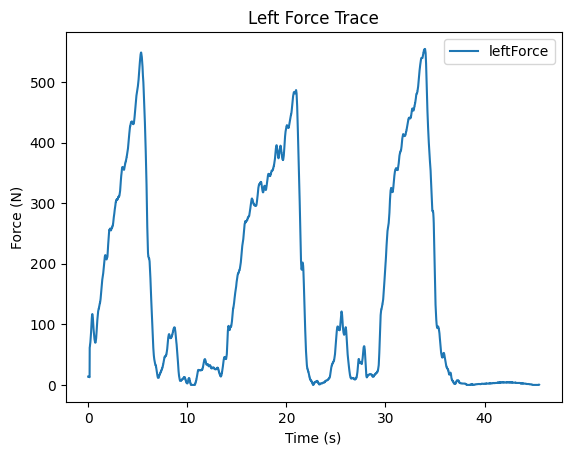

In [51]:
# To access raw force trace within API call response
nordbord.raw['forceTrace'].plot(x='Time',y='leftForce',title='Left Force Trace',xlabel='Time (s)',ylabel='Force (N)')